<!-- # Copyright (c) 2026 takotime808 -->
# Stacked VFM & Mixture of Experts

This notebook demonstrates two advanced surrogate model families in `multioutreg`:

### Stacked Variable Fidelity Models (VFM)
Multi-fidelity modelling combines **cheap, low-accuracy** simulations with **expensive, high-accuracy** data.  Two variants are covered:
- `StackedVFMSurrogate` — recursive feature augmentation (Perdikaris et al. 2017): each fidelity level receives the original features plus all lower-level predictions as extra inputs.
- `AdditiveCorrectionVFM` — Kennedy-O'Hagan AR1 style: high-fidelity = low-fidelity + learned correction.

### Mixture of Experts (MoE)
`MixtureOfExpertsSurrogate` partitions the input space into regions and trains a specialist surrogate per region, with a learned gating network that routes each query to the right expert.

## Contents
1. [Synthetic data](#synthetic-data)
2. [StackedVFMSurrogate — basics](#stacked-vfm-basics)
3. [Heterogeneous surrogates & uncertainty augmentation](#hetero-augment)
4. [Three-level VFM](#three-level)
5. [AdditiveCorrectionVFM](#additive)
6. [Conformal prediction on StackedVFM](#conformal-vfm)
7. [MixtureOfExpertsSurrogate — basics](#moe-basics)
8. [Routing weights & expert regions](#routing)
9. [Heterogeneous experts](#hetero-experts)
10. [Conformal prediction on MoE](#conformal-moe)
11. [Model comparison](#comparison)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import train_test_split

from multioutreg.surrogates import (
    RandomForestSurrogate,
    GaussianProcessSurrogate,
    GradientBoostingSurrogate,
    LinearRegressionSurrogate,
    StackedVFMSurrogate,
    AdditiveCorrectionVFM,
    MixtureOfExpertsSurrogate,
)

rng = np.random.default_rng(42)

<a id='synthetic-data'></a>
## 1. Synthetic Data

We create a two-output, two-input multi-fidelity benchmark where the fidelities differ by a nonlinear bias:

$$
Y_{lo}(x) = \sin(2\pi x_1) \cdot \cos(\pi x_2) \;+\; 0.5 x_1 x_2
$$
$$
Y_{hi}(x) = Y_{lo}(x) + 0.3 x_1^2 - 0.2 \sin(3\pi x_2)
$$

Low-fidelity data is plentiful (200 samples); high-fidelity data is scarce (40 samples).

In [2]:
def lo_fidelity(X):
    x1, x2 = X[:, 0], X[:, 1]
    y1 = np.sin(2 * np.pi * x1) * np.cos(np.pi * x2) + 0.5 * x1 * x2
    y2 = np.cos(2 * np.pi * x2) + 0.3 * x1
    return np.column_stack([y1, y2])

def hi_fidelity(X):
    Y_lo = lo_fidelity(X)
    x1, x2 = X[:, 0], X[:, 1]
    delta1 = 0.3 * x1**2 - 0.2 * np.sin(3 * np.pi * x2)
    delta2 = 0.15 * np.exp(-x1**2) * x2
    return Y_lo + np.column_stack([delta1, delta2])

# Low-fidelity: many cheap samples
X_lo = rng.uniform(-1, 1, (200, 2))
Y_lo = lo_fidelity(X_lo) + rng.normal(0, 0.05, (200, 2))

# High-fidelity: few expensive samples
X_hi = rng.uniform(-1, 1, (40, 2))
Y_hi = hi_fidelity(X_hi) + rng.normal(0, 0.02, (40, 2))

# Test set (ground truth high fidelity)
X_test = rng.uniform(-1, 1, (200, 2))
Y_test = hi_fidelity(X_test)

print(f"Low-fidelity:  X={X_lo.shape}, Y={Y_lo.shape}")
print(f"High-fidelity: X={X_hi.shape}, Y={Y_hi.shape}")
print(f"Test set:      X={X_test.shape}, Y={Y_test.shape}")

Low-fidelity:  X=(200, 2), Y=(200, 2)
High-fidelity: X=(40, 2), Y=(40, 2)
Test set:      X=(200, 2), Y=(200, 2)


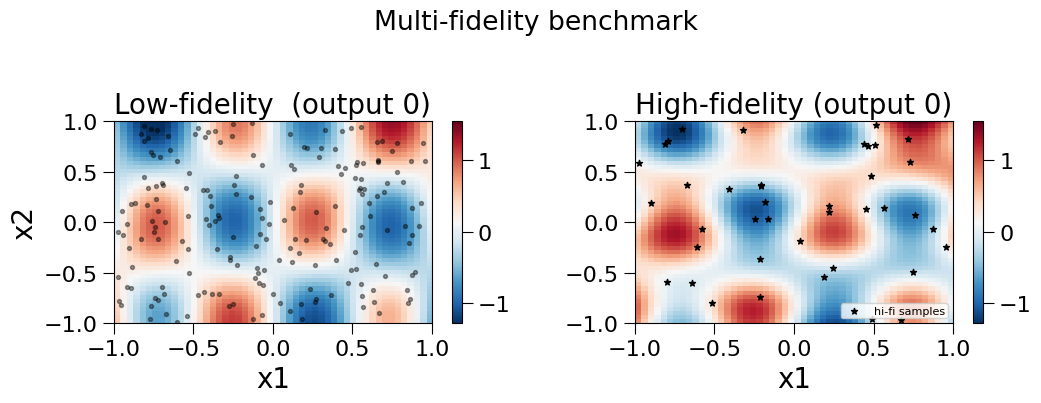

In [3]:
# Visualise the two fidelity levels on a grid (output 0)
grid_x = np.linspace(-1, 1, 50)
G1, G2 = np.meshgrid(grid_x, grid_x)
X_grid = np.column_stack([G1.ravel(), G2.ravel()])
Z_lo = lo_fidelity(X_grid)[:, 0].reshape(50, 50)
Z_hi = hi_fidelity(X_grid)[:, 0].reshape(50, 50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
kw = dict(origin="lower", extent=[-1, 1, -1, 1], aspect="auto", cmap="RdBu_r")
vmin, vmax = Z_hi.min(), Z_hi.max()

im0 = axes[0].imshow(Z_lo, vmin=vmin, vmax=vmax, **kw)
axes[0].scatter(X_lo[:, 0], X_lo[:, 1], s=8, c="k", alpha=0.4, label="lo-fi samples")
axes[0].set_title("Low-fidelity  (output 0)")
axes[0].set_xlabel("x1"); axes[0].set_ylabel("x2")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(Z_hi, vmin=vmin, vmax=vmax, **kw)
axes[1].scatter(X_hi[:, 0], X_hi[:, 1], s=20, c="k", marker="*", label="hi-fi samples")
axes[1].set_title("High-fidelity (output 0)")
axes[1].set_xlabel("x1")
axes[1].legend(fontsize=8)
plt.colorbar(im1, ax=axes[1])

plt.suptitle("Multi-fidelity benchmark", y=1.02)
plt.tight_layout()
plt.show()

<a id='stacked-vfm-basics'></a>
## 2. StackedVFMSurrogate — Basics

`StackedVFMSurrogate` expects a `data` dict mapping level names to `(X, Y)` tuples, ordered from lowest to highest fidelity.

At each level > 0 the feature matrix is augmented with all lower-level predictions before fitting, allowing the higher-level surrogate to learn a nonlinear correction.

In [4]:
data = {"lo": (X_lo, Y_lo), "hi": (X_hi, Y_hi)}

# Default: Random Forest at both levels
stacked = StackedVFMSurrogate(fidelity_levels=["lo", "hi"])
stacked.fit(data)

Y_pred_stacked = stacked.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(((y_true - y_pred) ** 2).mean(axis=0))

print("StackedVFM (RF/RF) RMSE per output:", rmse(Y_test, Y_pred_stacked).round(4))
print("Augmented feature counts:", stacked.augmented_n_features_per_level_)

StackedVFM (RF/RF) RMSE per output: [0.3229 0.1555]
Augmented feature counts: {'lo': 2, 'hi': 4}


In [5]:
# Baseline: train only on high-fidelity data (ignoring low-fidelity entirely)
baseline = RandomForestSurrogate()
baseline.fit(X_hi, Y_hi)
Y_pred_baseline = baseline.predict(X_test)

print("Baseline RF (hi only) RMSE:", rmse(Y_test, Y_pred_baseline).round(4))
print("StackedVFM (RF/RF)    RMSE:", rmse(Y_test, Y_pred_stacked).round(4))
print("\n→ Multi-fidelity improves accuracy by leveraging the abundant low-fi data.")

Baseline RF (hi only) RMSE: [0.487  0.2937]
StackedVFM (RF/RF)    RMSE: [0.3229 0.1555]

→ Multi-fidelity improves accuracy by leveraging the abundant low-fi data.


In [6]:
# You can predict at any fidelity level
Y_pred_lo_level = stacked.predict(X_test, level="lo")
Y_pred_hi_level = stacked.predict(X_test, level="hi")  # default

print("Predicting at low  level RMSE:", rmse(Y_test, Y_pred_lo_level).round(4))
print("Predicting at high level RMSE:", rmse(Y_test, Y_pred_hi_level).round(4))

Predicting at low  level RMSE: [0.3291 0.1313]
Predicting at high level RMSE: [0.3229 0.1555]


<a id='hetero-augment'></a>
## 3. Heterogeneous Surrogates & Uncertainty Augmentation

A common pattern is to use a fast surrogate (e.g. RF) at the low-fidelity level and a smooth, uncertainty-aware surrogate (e.g. GP) at the high-fidelity level.

Setting `augment_with_std=True` also passes predicted standard deviations from lower levels as features, letting the high-fidelity surrogate downweight regions where the low-fidelity surrogate is uncertain.

In [7]:
# RF at lo level, GP at hi level (smooth correction)
stacked_hetero = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
    surrogate_params=[{"n_estimators": 100}, {"alpha": 1e-6}],
    augment_with_std=True,   # pass RF uncertainty as extra feature to GP
)
stacked_hetero.fit(data)

Y_pred_hetero = stacked_hetero.predict(X_test)
Y_pred_hetero_std, Y_std_hetero = stacked_hetero.predict(X_test, return_std=True)

print("Hetero (RF→GP) RMSE:", rmse(Y_test, Y_pred_hetero).round(4))
print("Mean predicted std:  ", Y_std_hetero.mean(axis=0).round(4))
print("Augmented features:  ", stacked_hetero.augmented_n_features_per_level_)

Hetero (RF→GP) RMSE: [0.5027 0.1798]
Mean predicted std:   [0. 0.]
Augmented features:   {'lo': 2, 'hi': 6}


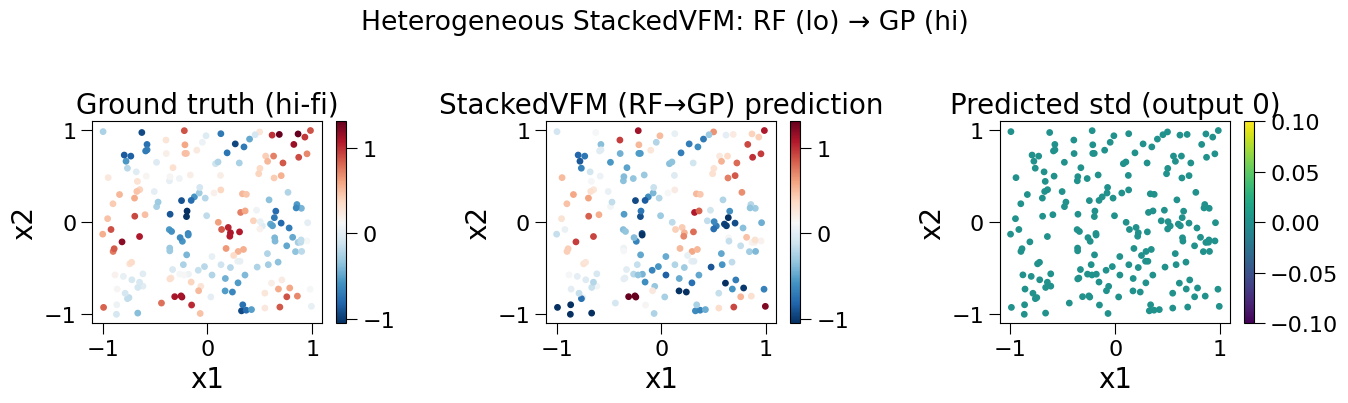

In [8]:
# Visualise predictions vs ground truth for output 0
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmin = Y_test[:, 0].min()
vmax = Y_test[:, 0].max()

sc0 = axes[0].scatter(X_test[:, 0], X_test[:, 1], c=Y_test[:, 0],
                       cmap="RdBu_r", vmin=vmin, vmax=vmax, s=15)
axes[0].set_title("Ground truth (hi-fi)")
plt.colorbar(sc0, ax=axes[0])

sc1 = axes[1].scatter(X_test[:, 0], X_test[:, 1], c=Y_pred_hetero[:, 0],
                       cmap="RdBu_r", vmin=vmin, vmax=vmax, s=15)
axes[1].set_title("StackedVFM (RF→GP) prediction")
plt.colorbar(sc1, ax=axes[1])

sc2 = axes[2].scatter(X_test[:, 0], X_test[:, 1], c=Y_std_hetero[:, 0],
                       cmap="viridis", s=15)
axes[2].set_title("Predicted std (output 0)")
plt.colorbar(sc2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.suptitle("Heterogeneous StackedVFM: RF (lo) → GP (hi)", y=1.02)
plt.tight_layout()
plt.show()

<a id='three-level'></a>
## 4. Three-Level VFM

`StackedVFMSurrogate` supports any number of levels. Here we add a "medium" fidelity tier between the cheap low-fi runs and the expensive high-fi experiments.

In [9]:
def med_fidelity(X):
    Y_lo = lo_fidelity(X)
    x1, x2 = X[:, 0], X[:, 1]
    delta1 = 0.15 * x1**2
    delta2 = 0.08 * np.exp(-x1**2) * x2
    return Y_lo + np.column_stack([delta1, delta2])

X_med = rng.uniform(-1, 1, (80, 2))
Y_med = med_fidelity(X_med) + rng.normal(0, 0.03, (80, 2))

data_3level = {
    "lo":  (X_lo,  Y_lo),
    "med": (X_med, Y_med),
    "hi":  (X_hi,  Y_hi),
}

stacked_3 = StackedVFMSurrogate(
    fidelity_levels=["lo", "med", "hi"],
    surrogate_cls=[
        RandomForestSurrogate,
        GradientBoostingSurrogate,
        GaussianProcessSurrogate,
    ],
)
stacked_3.fit(data_3level)

Y_pred_3 = stacked_3.predict(X_test)

print("Three-level VFM RMSE:          ", rmse(Y_test, Y_pred_3).round(4))
print("Two-level (RF→GP) RMSE:        ", rmse(Y_test, Y_pred_hetero).round(4))
print("Augmented feature sizes:", stacked_3.augmented_n_features_per_level_)

Three-level VFM RMSE:           [0.3512 0.1802]
Two-level (RF→GP) RMSE:         [0.5027 0.1798]
Augmented feature sizes: {'lo': 2, 'med': 4, 'hi': 6}


<a id='additive'></a>
## 5. AdditiveCorrectionVFM

`AdditiveCorrectionVFM` is a simpler two-level model that learns the correction  
$$f_{hi}(x) = f_{lo}(x) + \delta(x)$$

The correction $\delta(x)$ is trained on the residual at hi-fi locations.  Useful when the fidelity gap is well-approximated by a smooth additive shift.

`predict_components` exposes the two parts separately — useful for diagnosing how much correction is being applied.

In [10]:
additive = AdditiveCorrectionVFM(
    lo_surrogate_cls=RandomForestSurrogate,
    hi_surrogate_cls=GaussianProcessSurrogate,
    hi_surrogate_params={"alpha": 1e-6},
)
additive.fit(data)

Y_pred_add, Y_std_add = additive.predict(X_test, return_std=True)
Y_lo_part, Y_delta_part = additive.predict_components(X_test)

print("AdditiveCorrectionVFM RMSE:", rmse(Y_test, Y_pred_add).round(4))
print(f"Correction magnitude (|delta|): {np.abs(Y_delta_part).mean(axis=0).round(4)}")
print(f"Lo-fi magnitude      (|y_lo|):  {np.abs(Y_lo_part).mean(axis=0).round(4)}")

AdditiveCorrectionVFM RMSE: [0.6777 0.2492]
Correction magnitude (|delta|): [0.3571 0.1457]
Lo-fi magnitude      (|y_lo|):  [0.301  0.6373]


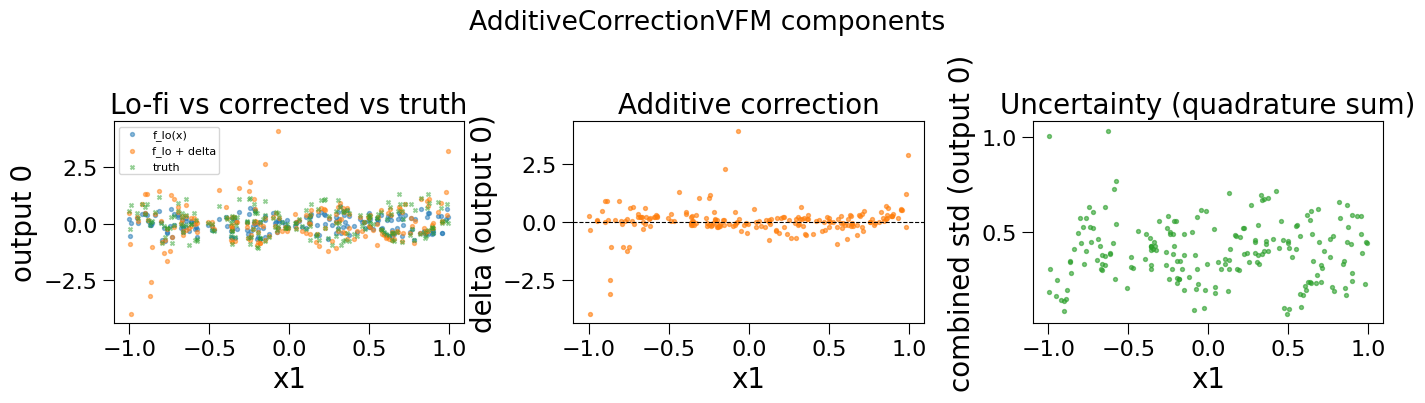

In [11]:
# Plot correction vs lo-fi prediction for output 0
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

ax = axes[0]
ax.scatter(X_test[:, 0], Y_lo_part[:, 0], s=8, alpha=0.5, label="f_lo(x)")
ax.scatter(X_test[:, 0], Y_pred_add[:, 0], s=8, alpha=0.5, label="f_lo + delta")
ax.scatter(X_test[:, 0], Y_test[:, 0], s=8, alpha=0.5, label="truth", marker="x")
ax.set_xlabel("x1"); ax.set_ylabel("output 0")
ax.set_title("Lo-fi vs corrected vs truth")
ax.legend(fontsize=8)

ax = axes[1]
ax.scatter(X_test[:, 0], Y_delta_part[:, 0], s=8, c="tab:orange", alpha=0.6)
ax.axhline(0, c="k", lw=0.8, ls="--")
ax.set_xlabel("x1"); ax.set_ylabel("delta (output 0)")
ax.set_title("Additive correction")

ax = axes[2]
ax.scatter(X_test[:, 0], Y_std_add[:, 0], s=8, c="tab:green", alpha=0.6)
ax.set_xlabel("x1"); ax.set_ylabel("combined std (output 0)")
ax.set_title("Uncertainty (quadrature sum)")

plt.suptitle("AdditiveCorrectionVFM components", y=1.02)
plt.tight_layout()
plt.show()

<a id='conformal-vfm'></a>
## 6. Conformal Prediction on StackedVFM

Both VFM classes inherit from `ConformalMixin`.  Call `wrap_conformal` with a held-out calibration set, then `conformal_predict` for distribution-free coverage-guaranteed intervals at any $\alpha$.

In [12]:
# Split hi-fi data into train and calibration
idx = rng.permutation(len(X_hi))
n_cal = 10
X_hi_train, Y_hi_train = X_hi[idx[n_cal:]], Y_hi[idx[n_cal:]]
X_hi_cal,   Y_hi_cal   = X_hi[idx[:n_cal]], Y_hi[idx[:n_cal]]

data_cal = {"lo": (X_lo, Y_lo), "hi": (X_hi_train, Y_hi_train)}

stacked_cp = StackedVFMSurrogate(
    fidelity_levels=["lo", "hi"],
    surrogate_cls=[RandomForestSurrogate, GaussianProcessSurrogate],
)
stacked_cp.fit(data_cal)

# Calibrate conformal intervals on held-out hi-fi points
stacked_cp.wrap_conformal(X_hi_cal, Y_hi_cal)

# Predict with 90% coverage guarantee
Y_lower, Y_upper = stacked_cp.conformal_predict(X_test, alpha=0.1)
Y_pred_cp = stacked_cp.predict(X_test)

coverage = np.mean((Y_test >= Y_lower) & (Y_test <= Y_upper), axis=0)
mean_width = (Y_upper - Y_lower).mean(axis=0)

print(f"Conformal coverage (target 90%): {coverage.round(3)}")
print(f"Mean interval width:              {mean_width.round(4)}")

Conformal coverage (target 90%): [0.865 0.99 ]
Mean interval width:              [1.6976 0.8709]


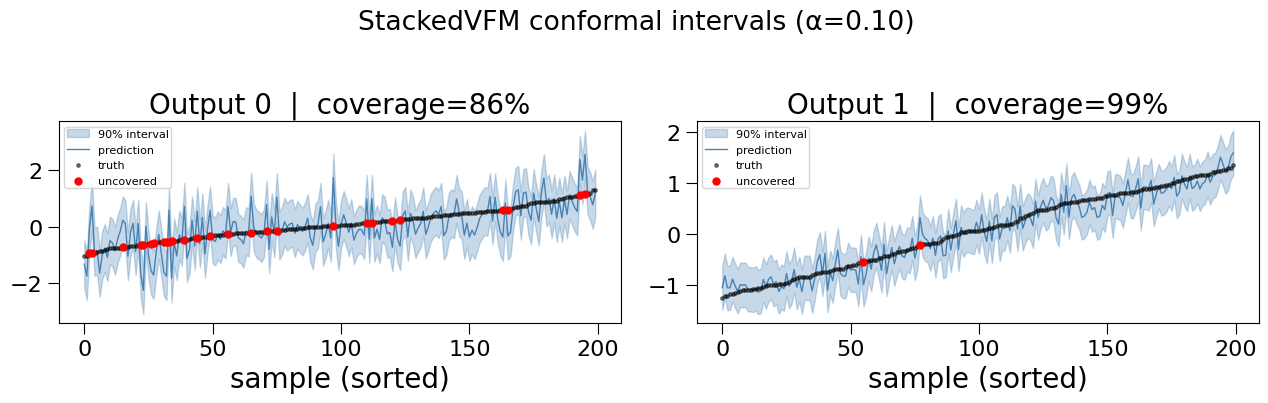

In [13]:
# Plot conformal intervals for both outputs
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for j, ax in enumerate(axes):
    order = np.argsort(Y_test[:, j])
    xs = np.arange(len(order))
    ax.fill_between(xs, Y_lower[order, j], Y_upper[order, j],
                    alpha=0.3, color="steelblue", label="90% interval")
    ax.plot(xs, Y_pred_cp[order, j], lw=1, color="steelblue", label="prediction")
    ax.scatter(xs, Y_test[order, j], s=6, color="k", alpha=0.5, label="truth", zorder=3)
    covered = (Y_test[order, j] >= Y_lower[order, j]) & (Y_test[order, j] <= Y_upper[order, j])
    ax.scatter(xs[~covered], Y_test[order][~covered, j],
               s=25, color="red", zorder=4, label="uncovered")
    ax.set_title(f"Output {j}  |  coverage={covered.mean():.0%}")
    ax.set_xlabel("sample (sorted)")
    ax.legend(fontsize=8, loc="upper left")

plt.suptitle("StackedVFM conformal intervals (α=0.10)", y=1.02)
plt.tight_layout()
plt.show()

<a id='moe-basics'></a>
## 7. MixtureOfExpertsSurrogate — Basics

`MixtureOfExpertsSurrogate` partitions the input space and trains a specialist surrogate per region via a hard-EM loop:

1. **M-step**: fit each expert on its currently assigned samples.
2. **E-step**: re-assign each sample to the expert with the highest gating weight.
3. Repeat until assignments converge.

At prediction time either **soft routing** (weighted sum over all experts) or **hard routing** (single best expert) can be used.  Soft routing uncertainty is the weighted variance of expert disagreement.

In [14]:
# Generate data with clear regional structure (useful for MoE)
# Two modes: smooth region and oscillating region
n_moe = 400
X_moe = rng.uniform(-2, 2, (n_moe, 2))

def moe_target(X):
    x1, x2 = X[:, 0], X[:, 1]
    # Region 1 (x1 < 0): smooth quadratic
    y1_r1 = x1**2 + x2
    # Region 2 (x1 >= 0): oscillating
    y1_r2 = np.sin(3 * x1) * np.cos(2 * x2)
    y1 = np.where(x1 < 0, y1_r1, y1_r2)
    y2 = np.tanh(x1 * x2)
    return np.column_stack([y1, y2])

Y_moe = moe_target(X_moe) + rng.normal(0, 0.05, (n_moe, 2))

X_moe_train, X_moe_test, Y_moe_train, Y_moe_test = train_test_split(
    X_moe, Y_moe, test_size=0.2, random_state=42
)

# Basic MoE: 4 RF experts, linear gating, soft routing
moe = MixtureOfExpertsSurrogate(
    n_experts=4,
    expert_type=RandomForestSurrogate,
    gating_type="linear",
    routing="soft",
    random_state=0,
)
moe.fit(X_moe_train, Y_moe_train)

Y_pred_moe, Y_std_moe = moe.predict(X_moe_test, return_std=True)

print("MoE (4 RF, linear gate) RMSE:", rmse(Y_moe_test, Y_pred_moe).round(4))
print("Mean expert-disagreement std:", Y_std_moe.mean(axis=0).round(4))

MoE (4 RF, linear gate) RMSE: [0.2018 0.0917]
Mean expert-disagreement std: [0.084  0.0762]


In [15]:
# Compare soft vs hard routing
moe_hard = MixtureOfExpertsSurrogate(
    n_experts=4,
    expert_type=RandomForestSurrogate,
    routing="hard",
    random_state=0,
)
moe_hard.fit(X_moe_train, Y_moe_train)
Y_pred_hard = moe_hard.predict(X_moe_test)

# Single RF baseline
single_rf = RandomForestSurrogate()
single_rf.fit(X_moe_train, Y_moe_train)
Y_pred_single = single_rf.predict(X_moe_test)

print("Single RF           RMSE:", rmse(Y_moe_test, Y_pred_single).round(4))
print("MoE soft routing    RMSE:", rmse(Y_moe_test, Y_pred_moe).round(4))
print("MoE hard routing    RMSE:", rmse(Y_moe_test, Y_pred_hard).round(4))

Single RF           RMSE: [0.1923 0.1249]
MoE soft routing    RMSE: [0.2018 0.0917]
MoE hard routing    RMSE: [0.2042 0.0903]


<a id='routing'></a>
## 8. Routing Weights & Expert Regions

`get_routing_weights(X)` returns a `(n_samples, n_experts)` array of gating probabilities, showing which expert is responsible for each region of input space.

In [16]:
weights = moe.get_routing_weights(X_moe_test)  # (n_test, 4)
dominant_expert = weights.argmax(axis=1)

print("Gating weight stats (mean per expert):", weights.mean(axis=0).round(3))
print("Expert assignment counts:",
      {k: (dominant_expert == k).sum() for k in range(moe.n_experts)})

Gating weight stats (mean per expert): [0.14 0.   0.   0.86]
Expert assignment counts: {0: 10, 1: 0, 2: 0, 3: 70}


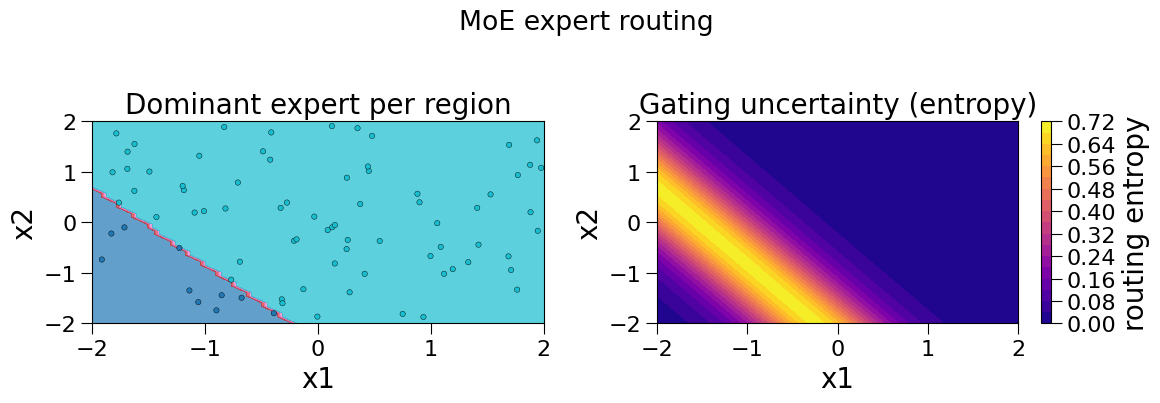

In [17]:
# Visualise expert territories and gating weights on a grid
grid = np.linspace(-2, 2, 60)
G1, G2 = np.meshgrid(grid, grid)
X_g = np.column_stack([G1.ravel(), G2.ravel()])
W_grid = moe.get_routing_weights(X_g)  # (3600, 4)
dom = W_grid.argmax(axis=1).reshape(60, 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cmap = plt.cm.get_cmap("tab10", moe.n_experts)
ax = axes[0]
ax.contourf(G1, G2, dom, levels=np.arange(-0.5, moe.n_experts), cmap=cmap, alpha=0.7)
ax.scatter(X_moe_test[:, 0], X_moe_test[:, 1], c=dominant_expert,
           cmap=cmap, vmin=0, vmax=moe.n_experts - 1, s=15, edgecolors="k", lw=0.3)
ax.set_title("Dominant expert per region")
ax.set_xlabel("x1"); ax.set_ylabel("x2")

ax = axes[1]
entropy = -(W_grid * np.log(W_grid + 1e-12)).sum(axis=1).reshape(60, 60)
cf = ax.contourf(G1, G2, entropy, cmap="plasma", levels=20)
plt.colorbar(cf, ax=ax, label="routing entropy")
ax.set_title("Gating uncertainty (entropy)")
ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.suptitle("MoE expert routing", y=1.02)
plt.tight_layout()
plt.show()

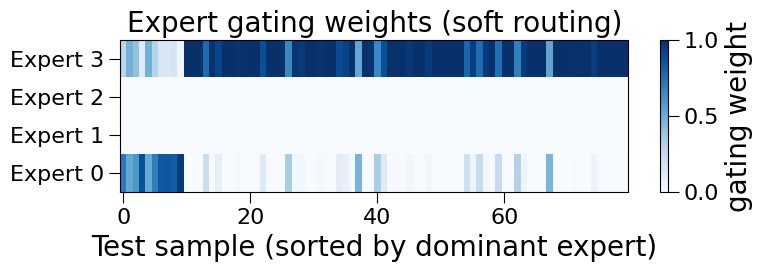

In [18]:
# Gating weight heatmap for the test set
fig, ax = plt.subplots(figsize=(8, 3))
order = np.argsort(dominant_expert)
im = ax.imshow(weights[order].T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
ax.set_yticks(range(moe.n_experts))
ax.set_yticklabels([f"Expert {k}" for k in range(moe.n_experts)])
ax.set_xlabel("Test sample (sorted by dominant expert)")
plt.colorbar(im, ax=ax, label="gating weight")
ax.set_title("Expert gating weights (soft routing)")
plt.tight_layout()
plt.show()

<a id='hetero-experts'></a>
## 9. Heterogeneous Experts

By passing a list to `expert_type`, each slot can use a different surrogate class.  This is useful when different regions of input space have fundamentally different response characters (e.g. smooth vs. oscillating).

In [19]:
# MLP gating + heterogeneous experts
moe_hetero = MixtureOfExpertsSurrogate(
    n_experts=4,
    expert_type=[
        GaussianProcessSurrogate,    # smooth region
        GradientBoostingSurrogate,   # non-smooth region
        RandomForestSurrogate,       # general
        LinearRegressionSurrogate,   # near-linear zone
    ],
    expert_params=[
        {"alpha": 1e-6},
        {"n_estimators": 100},
        {"n_estimators": 100},
        {},
    ],
    gating_type="mlp",
    routing="soft",
    random_state=1,
)
moe_hetero.fit(X_moe_train, Y_moe_train)
Y_pred_hetero_moe, Y_std_hetero_moe = moe_hetero.predict(X_moe_test, return_std=True)

print("Hetero MoE (GP/GBM/RF/LR, MLP gate) RMSE:", rmse(Y_moe_test, Y_pred_hetero_moe).round(4))
print("Single RF baseline                   RMSE:", rmse(Y_moe_test, Y_pred_single).round(4))

Hetero MoE (GP/GBM/RF/LR, MLP gate) RMSE: [0.7294 0.5445]
Single RF baseline                   RMSE: [0.1923 0.1249]


<a id='conformal-moe'></a>
## 10. Conformal Prediction on MoE

`MixtureOfExpertsSurrogate` also inherits `ConformalMixin`, so the same `wrap_conformal` / `conformal_predict` workflow applies.

In [20]:
# Split training data into fit and calibration
X_fit, X_cal_moe, Y_fit, Y_cal_moe = train_test_split(
    X_moe_train, Y_moe_train, test_size=0.2, random_state=7
)

moe_cp = MixtureOfExpertsSurrogate(
    n_experts=4,
    expert_type=RandomForestSurrogate,
    gating_type="mlp",
    routing="soft",
    random_state=0,
)
moe_cp.fit(X_fit, Y_fit)
moe_cp.wrap_conformal(X_cal_moe, Y_cal_moe)

Y_lower_moe, Y_upper_moe = moe_cp.conformal_predict(X_moe_test, alpha=0.1)
Y_pred_moe_cp = moe_cp.predict(X_moe_test)

coverage_moe = np.mean(
    (Y_moe_test >= Y_lower_moe) & (Y_moe_test <= Y_upper_moe), axis=0
)
width_moe = (Y_upper_moe - Y_lower_moe).mean(axis=0)

print(f"MoE conformal coverage (target 90%): {coverage_moe.round(3)}")
print(f"Mean interval width:                 {width_moe.round(4)}")

MoE conformal coverage (target 90%): [0.812 0.775]
Mean interval width:                 [0.8069 0.2807]


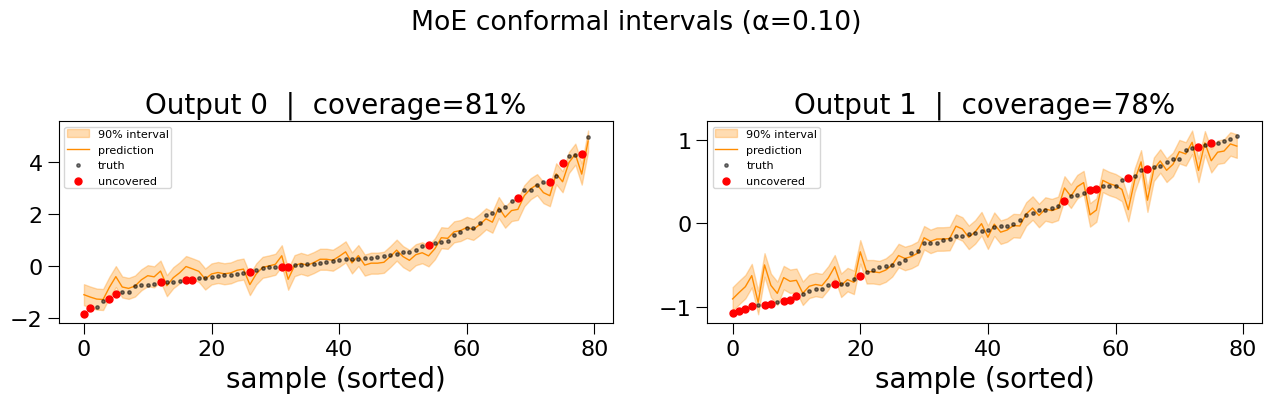

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for j, ax in enumerate(axes):
    order = np.argsort(Y_moe_test[:, j])
    xs = np.arange(len(order))
    ax.fill_between(xs, Y_lower_moe[order, j], Y_upper_moe[order, j],
                    alpha=0.3, color="darkorange", label="90% interval")
    ax.plot(xs, Y_pred_moe_cp[order, j], lw=1, color="darkorange", label="prediction")
    ax.scatter(xs, Y_moe_test[order, j], s=6, color="k", alpha=0.5, label="truth", zorder=3)
    covered = (
        (Y_moe_test[order, j] >= Y_lower_moe[order, j]) &
        (Y_moe_test[order, j] <= Y_upper_moe[order, j])
    )
    ax.scatter(xs[~covered], Y_moe_test[order][~covered, j],
               s=25, color="red", zorder=4, label="uncovered")
    ax.set_title(f"Output {j}  |  coverage={covered.mean():.0%}")
    ax.set_xlabel("sample (sorted)")
    ax.legend(fontsize=8, loc="upper left")

plt.suptitle("MoE conformal intervals (α=0.10)", y=1.02)
plt.tight_layout()
plt.show()

<a id='comparison'></a>
## 11. Model Comparison

Summary of RMSE across the approaches explored in this notebook on the multi-fidelity test set.

In [22]:
import pandas as pd

results = [
    ("Baseline RF (hi only)",          rmse(Y_test, Y_pred_baseline)),
    ("StackedVFM (RF/RF)",             rmse(Y_test, Y_pred_stacked)),
    ("StackedVFM (RF→GP, std aug)",    rmse(Y_test, Y_pred_hetero)),
    ("StackedVFM (3 levels)",          rmse(Y_test, Y_pred_3)),
    ("AdditiveCorrectionVFM (RF+GP)",  rmse(Y_test, Y_pred_add)),
]

df = pd.DataFrame(
    [(name, r[0], r[1]) for name, r in results],
    columns=["Model", "RMSE output 0", "RMSE output 1"],
)
df = df.round(4)
df

,Model,RMSE output 0,RMSE output 1
0,Baseline RF (hi only),0.4870,0.2937
1,StackedVFM (RF/RF),0.3229,0.1555
2,"StackedVFM (RF→GP, std aug)",0.5027,0.1798
3,StackedVFM (3 levels),0.3512,0.1802
4,AdditiveCorrectionVFM (RF+GP),0.6777,0.2492


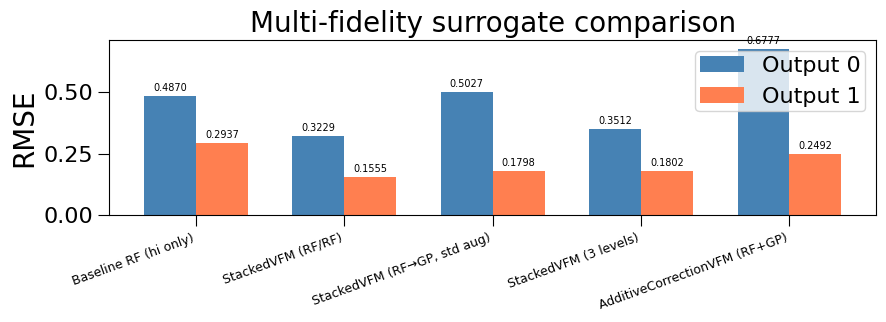

In [23]:
fig, ax = plt.subplots(figsize=(9, 3.5))

x = np.arange(len(df))
w = 0.35
bars0 = ax.bar(x - w/2, df["RMSE output 0"], w, label="Output 0", color="steelblue")
bars1 = ax.bar(x + w/2, df["RMSE output 1"], w, label="Output 1", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(df["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("RMSE")
ax.set_title("Multi-fidelity surrogate comparison")
ax.legend()
ax.bar_label(bars0, fmt="%.4f", fontsize=7, padding=2)
ax.bar_label(bars1, fmt="%.4f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

## Summary

| Class | Use when |
|---|---|
| `StackedVFMSurrogate` | You have 2+ fidelity levels; want nonlinear cross-fidelity correction; can mix any surrogates |
| `AdditiveCorrectionVFM` | Two-level problem; fidelity gap is approximately additive; want simple diagnostics via `predict_components` |
| `MixtureOfExpertsSurrogate` | Input space has distinct regimes; specialist models outperform a global fit; want interpretable routing |

All three classes inherit `ConformalMixin`, so distribution-free prediction intervals are always available via `wrap_conformal` + `conformal_predict`.